### Work function:PROPERTIES:



[BROKEN LINK: index:work function]
To get the work function, we need to have the local potential. This is not written by default in VASP, and we have to tell it to do that with the [BROKEN LINK: incar:LVTOT] and [BROKEN LINK: incar:LVHAR] keywords.



/opt/conda/lib/python3.9/site-packages/ase/lattice/surface.py:17: UserWarning: Moved to ase.build
  warnings.warn('Moved to ase.build')


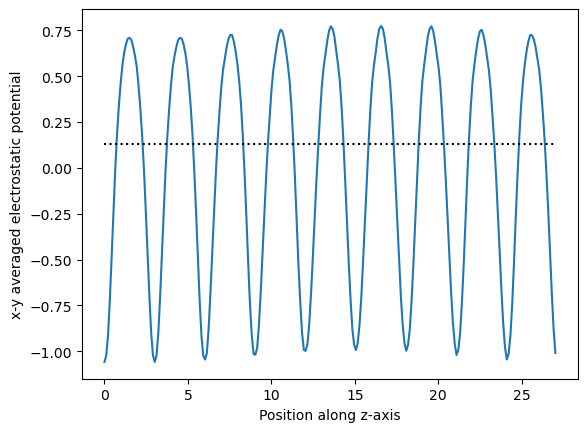

 The workfunction is -0.06 eV


In [1]:
from vasp import Vasp
from ase.lattice.surface import fcc111
from ase.constraints import FixAtoms
import matplotlib.pyplot as plt
import numpy as np

# Create a fresh Al slab
atoms = fcc111('Al', size=(1, 1, 4), vacuum=10.0)
constraint = FixAtoms(mask=[atom.tag >= 3 for atom in atoms])
atoms.set_constraint(constraint)

calc = Vasp('surfaces/Al-slab-locpot',
            xc='PBE',
            kpts=[6, 6, 1],
            encut=350,
            lvtot=True,  # write out local potential
            lvhar=True,  # write out only electrostatic potential, not xc pot
            atoms=atoms)

# Run the calculation
energy = calc.get_potential_energy()

ef = calc.get_fermi_level()
grid_points, lp = calc.get_local_potential()

# Average over x-y plane
nz = lp.shape[2]
axy = np.array([np.average(lp[:, :, z]) for z in range(nz)])

# Setup the x-axis in realspace
uc = atoms.get_cell()
xaxis = np.linspace(0, uc[2][2], nz)

plt.plot(xaxis, axy)
plt.plot([min(xaxis), max(xaxis)], [ef, ef], 'k:')
plt.xlabel('Position along z-axis')
plt.ylabel('x-y averaged electrostatic potential')
plt.show()

ind = (xaxis > 0) & (xaxis < 5)
wf = np.average(axy[ind]) - ef
print(f' The workfunction is {wf:1.2f} eV')

    The workfunction is 4.17 eV

The workfunction of Al is listed as 4.08 at [http://hyperphysics.phy-astr.gsu.edu/hbase/tables/photoelec.html](http://hyperphysics.phy-astr.gsu.edu/hbase/tables/photoelec.html).

![img](./images/Al-wf.png "$xy$ averaged local electrostatic potential of an Al(111) slab.")

